## Dataset overview

In [26]:
import torch
from torch.utils.data import Dataset

class FibonacciModDataset(Dataset):
    def __init__(self, seq_len=10, mod=10, num_samples=10000):
        self.mod = mod

        self.global_seq = self.generate_fib_sequence(1000, mod)
        self.samples = []
        for _ in range(num_samples):
            start_idx = torch.randint(0, len(self.global_seq) - seq_len - 1, (1,)).item()
            seq = self.global_seq[start_idx:start_idx + seq_len + 1]
            x = torch.tensor(seq[:-1], dtype=torch.long)
            y = torch.tensor(seq[1:], dtype=torch.long)
            self.samples.append((x, y))

    def generate_fib_sequence(self, length, mod):
        seq = [1, 1] # these are the starting values
        while len(seq) < length: # this prevents overlap
            seq.append((seq[-1] + seq[-2]) % mod)
        return seq
    
generated_ds = FibonacciModDataset(num_samples=20, mod=10, seq_len=20)
print(generated_ds.generate_fib_sequence(20, 10))

[1, 1, 2, 3, 5, 8, 3, 1, 4, 5, 9, 4, 3, 7, 0, 7, 7, 4, 1, 5]


## Probability concepts

Entropy H(X) = sum (p(x) log p(x))


<style>
.custom-table {
    border-collapse: collapse;
    width: 40%;
    font-family: Arial, sans-serif;
    text-align: center;
}


</style>
<caption>Equal Probability</caption>
<table class="custom-table">
<tr>
    <th>Outcome</th>
    <th>Probability</th>
</tr>
<tr>
    <td>A</td>
    <td>0.5</td>
</tr>
<tr>
    <td>B</td>
    <td>0.5</td>
</tr>
</table>

<hr />
<caption>Unequal Probability</caption>
<table class="custom-table">
<tr>
    <th>Outcome</th>
    <th>Probability</th>
</tr>
<tr>
    <td>A</td>
    <td>0.9</td>
</tr>
<tr>
    <td>B</td>
    <td>0.05</td>
</tr>
</table>

<hr />


At first you cannot really predict, H(x) high

At second you can be almost right, H(x) low

Entropy H(x) is the measure of disorder or radnomness like we learned in shcool, second law.


Uncertinity of X by oberving Y, H(X|Y), if that Y happens to tell nothing then H(X|Y) = H(X)


`Mutual Information` : How much Y reduces Uncertinity of X

I(X;Y)=H(X)−H(X∣Y)



## Relation with our project

I(Y ; X₁, X₂)  — total mutual information with both inputs <b>How much X1, and X2 reduces uncertinity of Y</b> <i>information available only when both are known together</i>

I(Y ; X₁)      — info from F(n-1) alone  

I(Y ; X₂)      — info from F(n-2) alone


Synergy = I(Y ; X₁, X₂) − I(Y ; X₁) − I(Y ; X₂)


If Synergy > 0 and large model needs both number together.


<b> II = I(Y ; X₁) + I(Y ; X₂) − I(Y ; X₁, X₂) </b>

If II < 0 then; synergy dominates → model uses both jointly

If II > 0 then; redundancy dominates → model uses one input and the other adds little → no fetch

If II ≈ 0 → inputs are independent contributors, borderline


Pt: d(II)/d(t) has a sharp negative spike, over epoch maybe

<hr />

<b>
II = I(Y ; X₁) + I(Y ; X₂) − I(Y ; X₁, X₂) <I>(Joined Part)</I>
</b>

II > 0  →  joint < sum of parts  →  overlap existed  →  redundancy

II < 0  →  joint > sum of parts →  combination beat both  →  synergy

II = 0  →  joint = sum of parts  →  independent contributions

<hr />

I(Y ; X₁, X₂) measures how much uncertainty about Y disappears when you know both X₁ and X₂ together.


<hr />

For Our Model

II > 0   model found a shortcut where one input suffices   bad


II < 0   model genuinely needs both inputs together        good, fetch confirmed

<hr />

<b>II < 0</b>

I(Y ; X₁)        = 0.3


I(Y ; X₂)        = 0.3


I(Y ; X₁, X₂)    = 3.3   ← joint is huge relative to individuals

II = 0.3 + 0.3 − 3.3 = −2.7   negative


<b>II > 0</b>

I(Y ; X₁)        = 3.0   ← each alone already explains Y well

I(Y ; X₂)        = 3.0   ← same explanation, just repeated

I(Y ; X₁, X₂)    = 3.2   ← joint barely grows because nothing new added

II = 3.0 + 3.0 − 3.2 = +2.8   positive

<b>That idea is rejected we have `mod`</b>

## Going further into our analysis

Polar coordinates

Euler formula says that if we take `e^some_number.i ` we will be able to land that number of units on a unit circle with radius of 1, counter clock wise.

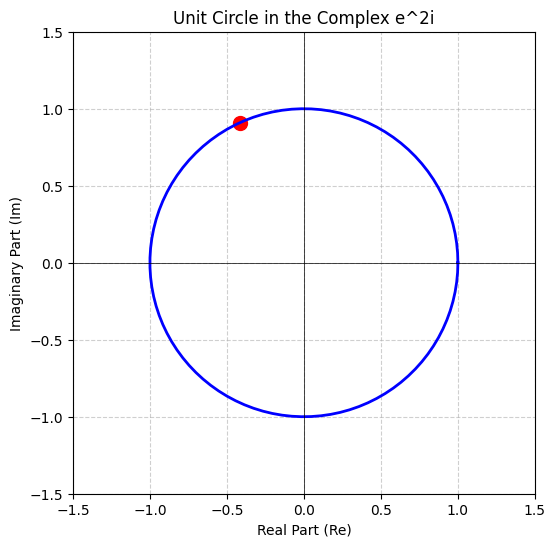

In [27]:
import matplotlib.pyplot as plt
import numpy as np

theta = np.linspace(0, 2 * np.pi, 100) 

# Paramatric eqn not the effiective way in computer graphics but will work here
x = np.cos(theta) 
y = np.sin(theta)

z = np.exp(2j)

x_point = z.real
y_point = z.imag


fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x, y, color='blue', linewidth=2)


ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_aspect('equal')

ax.scatter(x_point, y_point, color='red', s=100, 
           label=f'$e^{{2i}} \\approx {x_point:.3f} + {y_point:.3f}i$')


ax.set_xlabel('Real Part (Re)')
ax.set_ylabel('Imaginary Part (Im)')
ax.set_title('Unit Circle in the Complex e^2i')
ax.grid(True, linestyle='--', alpha=0.6)


ax.axhline(0, color='black',linewidth=0.5)
ax.axvline(0, color='black',linewidth=0.5)


plt.show()




Let's define rotating at a rate of one cycle per second!

In [1]:
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import numpy as np
import math

theta = np.linspace(0, 2 * np.pi, 100) 


x = np.cos(theta) 
y = np.sin(theta)

# t : where we are at, f: how much time does it take to complate one full lap
def change_plot_on_interaction(t = 0, f=1/5):
    angular_rotation_W = 2 * math.pi * f
    z = np.exp(1j * angular_rotation_W * t)

    x_point = z.real
    y_point = z.imag

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(x, y, color='blue', linewidth=2)


    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal')

    ax.scatter(x_point, y_point, color='red', s=100, 
            label=f'$e^{{2i}} \\approx {x_point:.3f} + {y_point:.3f}i$')


    ax.set_xlabel('Real Part (Re)')
    ax.set_ylabel('Imaginary Part (Im)')
    ax.set_title('Unit Circle in the Complex e^2i')
    ax.grid(True, linestyle='--', alpha=0.6)


    ax.axhline(0, color='black',linewidth=0.5)
    ax.axvline(0, color='black',linewidth=0.5)

    plt.show()

interact(change_plot_on_interaction, t=FloatSlider(min=0, max=10, step=0.1, value=0))

interactive(children=(FloatSlider(value=0.0, description='t', max=10.0), FloatSlider(value=0.2, description='f…

<function __main__.change_plot_on_interaction(t=0, f=0.2)>

## Let's try to wrap that sine waive into this expression

Let's imagine we are winding that sine waive, I don't want to plot it takes time.

In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import numpy as np
import math

theta = np.linspace(0, 2 * np.pi, 100) 


x = np.cos(theta) 
y = np.sin(theta)

def change_plot_on_interaction(t = 0, f=1/5):
    angular_rotation_W = (2 * math.pi * f) * np.sin(t)
    z = np.exp(1j * angular_rotation_W * t)

    x_point = z.real
    y_point = z.imag

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(x, y, color='blue', linewidth=2)


    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal')

    ax.scatter(x_point, y_point, color='red', s=100, 
            label=f'$e^{{2i}} \\approx {x_point:.3f} + {y_point:.3f}i$')


    ax.set_xlabel('Real Part (Re)')
    ax.set_ylabel('Imaginary Part (Im)')
    ax.set_title('Unit Circle in the Complex e^2i')
    ax.grid(True, linestyle='--', alpha=0.6)


    ax.axhline(0, color='black',linewidth=0.5)
    ax.axvline(0, color='black',linewidth=0.5)

    plt.show()

interact(change_plot_on_interaction, t=FloatSlider(min=0, max=10, step=0.1, value=0))

interactive(children=(FloatSlider(value=0.0, description='t', max=10.0), FloatSlider(value=0.2, description='f…

<function __main__.change_plot_on_interaction(t=0, f=0.2)>

Let us assume that sin(theta) = f(x)

we can say that f(x) e^2pi * f * t wraps the winding of that waive in circle.


What I think of it was a gravitational slingshot not eactly but some sort of orbit hwatever which has like a point in space that goes with it wherever it goes.


That is necessary cause we are trying to derive Fouirer Series.


∫ f(X) * e^2pi * f * t dx t1 to t2 as a limit